
══════════════════════════════════════
   PEMBANGKITAN KURVA PARAMETRIK   
══════════════════════════════════════
  1.  Lingkaran
  2.  Elips
  3.  Parabola
  4.  Hiperbola
  0.  Keluar
──────────────────────────────────────

─── HIPERBOLA ──────────────────────────

════════════════════════════════════════════
  KOORDINAT HIPERBOLA  (Cabang Kanan, 4 titik)
════════════════════════════════════════════
  Titik   1: (   14.9533,   -10.8063)
  Titik   2: (    4.0201,    -0.3010)
  Titik   3: (    8.8184,     5.8943)
  Titik   4: (   -6.0035,    -3.3576)


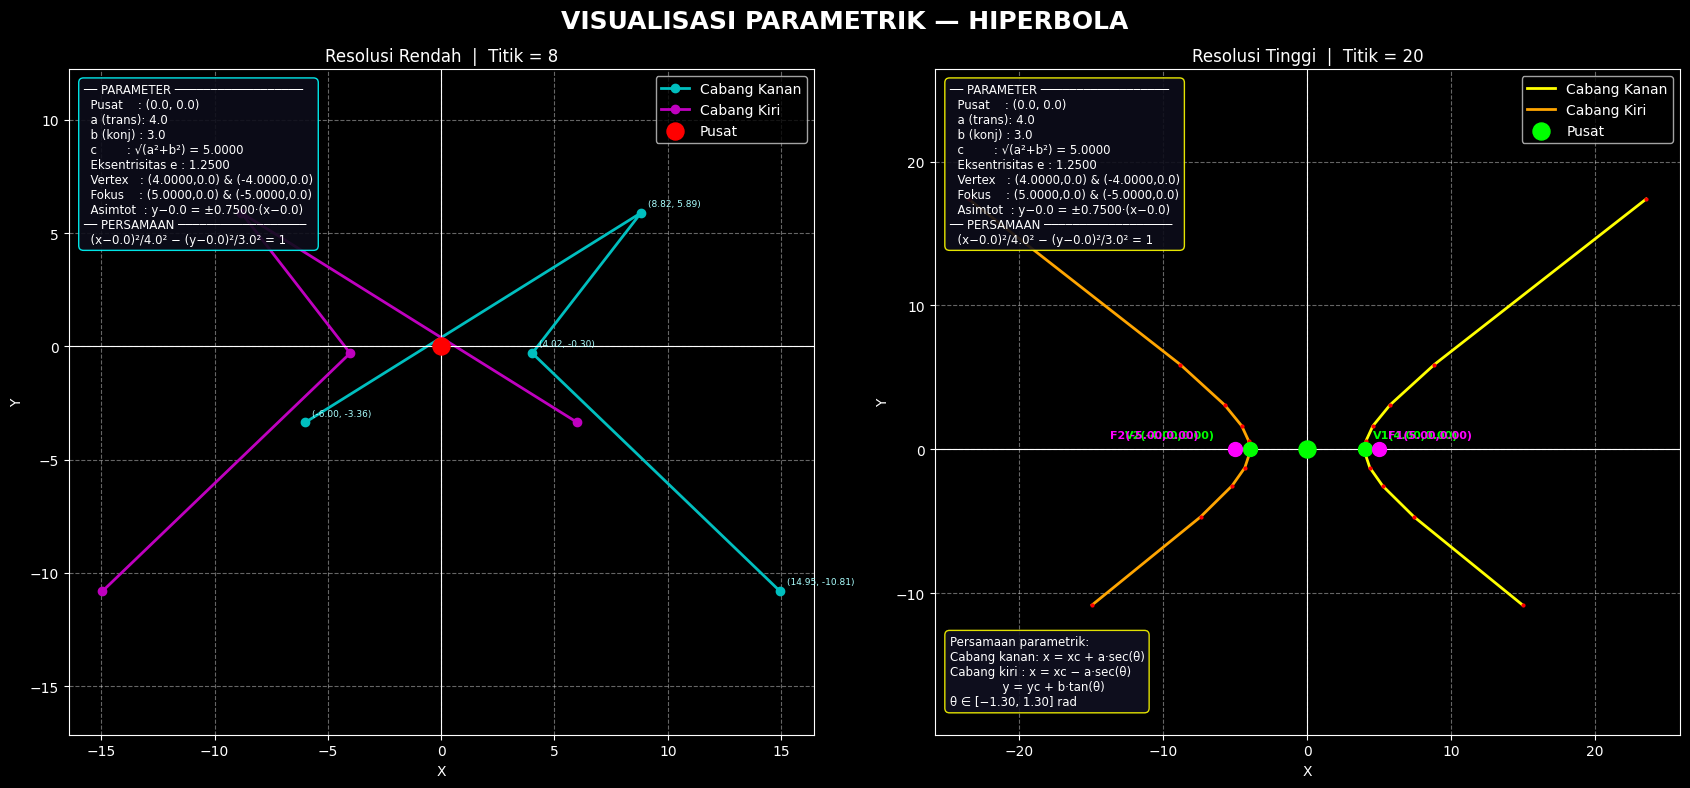


══════════════════════════════════════
   PEMBANGKITAN KURVA PARAMETRIK   
══════════════════════════════════════
  1.  Lingkaran
  2.  Elips
  3.  Parabola
  4.  Hiperbola
  0.  Keluar
──────────────────────────────────────

─── HIPERBOLA ──────────────────────────

════════════════════════════════════════════
  KOORDINAT HIPERBOLA  (Cabang Kanan, 10 titik)
════════════════════════════════════════════
  Titik   1: (   14.9533,   -10.8063)
  Titik   2: (    7.4033,    -4.6722)
  Titik   3: (    5.2298,    -2.5269)
  Titik   4: (    4.3428,    -1.2684)
  Titik   5: (    4.0201,    -0.3010)
  Titik   6: (    4.0814,     0.6081)
  Titik   7: (    4.5580,     1.6389)
  Titik   8: (    5.7413,     3.0889)
  Titik   9: (    8.8184,     5.8943)
  Titik  10: (   23.5340,    17.3937)


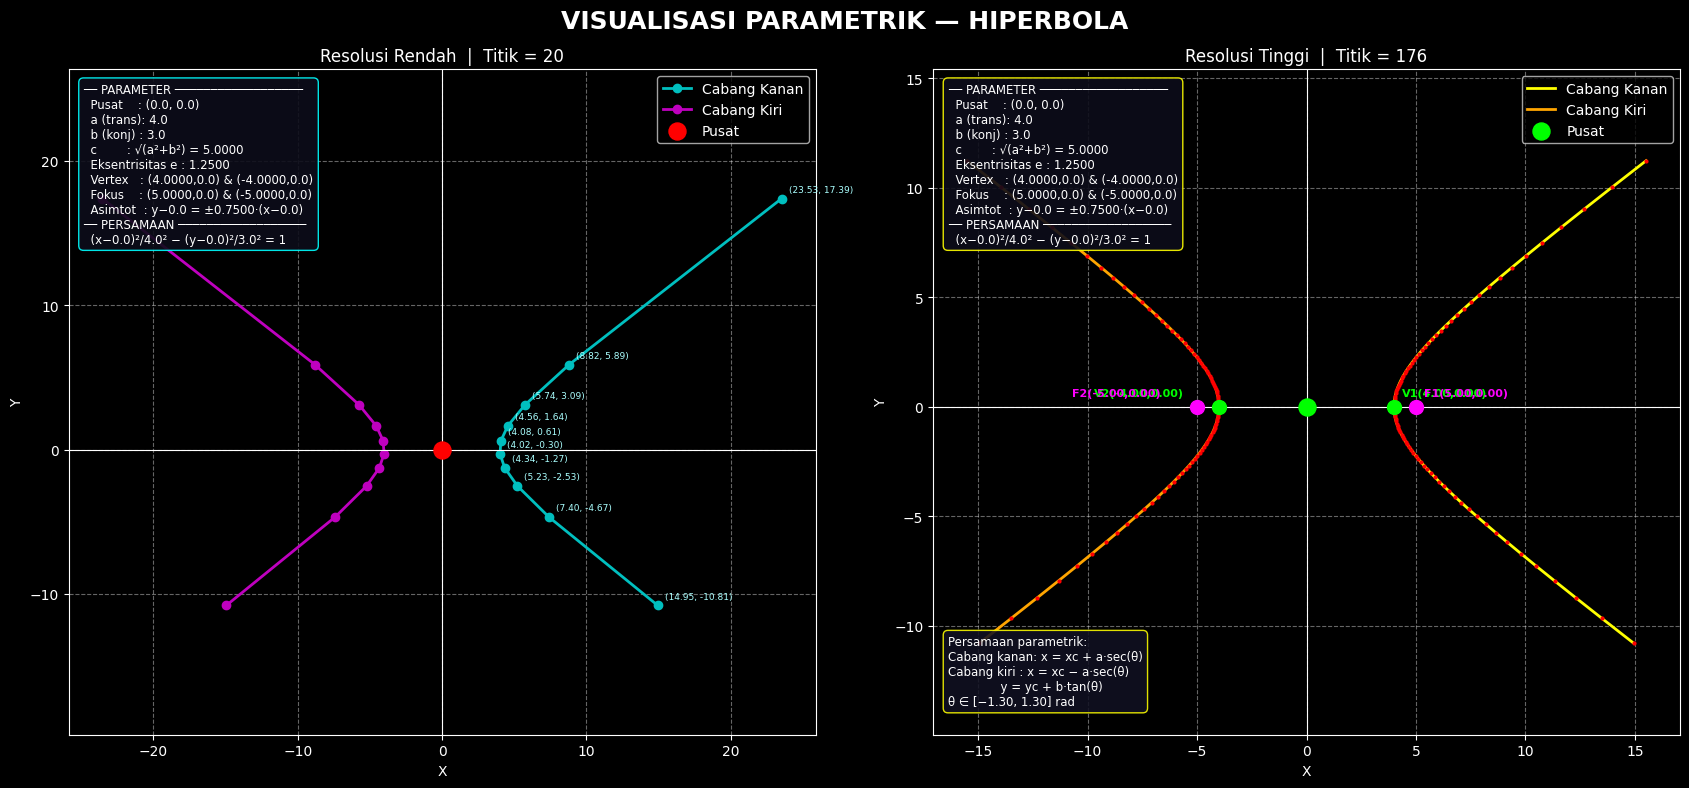


══════════════════════════════════════
   PEMBANGKITAN KURVA PARAMETRIK   
══════════════════════════════════════
  1.  Lingkaran
  2.  Elips
  3.  Parabola
  4.  Hiperbola
  0.  Keluar
──────────────────────────────────────

  Program selesai. Sampai jumpa!



In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('dark_background')


# =====================================================
# HELPER — buat kotak info parameter di dalam gambar
# =====================================================

def box_info(ax, lines, x=0.02, y=0.98, edge='cyan'):
    """Tampilkan kotak teks info parameter di pojok kiri atas panel."""
    teks = "\n".join(lines)
    ax.text(
        x, y, teks,
        transform=ax.transAxes,
        fontsize=8.5,
        color='white',
        verticalalignment='top',
        bbox=dict(facecolor='#0d0d1a', edgecolor=edge,
                  alpha=0.90, pad=6, boxstyle='round,pad=0.4')
    )


def tandai_titik(ax, x, y, label, color='red', offset=(5, 5), fs=8):
    """Plot satu titik istimewa + label."""
    ax.scatter(x, y, color=color, s=100, zorder=6)
    ax.annotate(label, (x, y),
                textcoords="offset points", xytext=offset,
                fontsize=fs, color=color,
                fontweight='bold')


# =====================================================
# VISUALISASI UMUM (Lingkaran, Elips, Parabola)
# =====================================================

def tampilkan(x_low, y_low, x_high, y_high,
              judul, center_x=0, center_y=0,
              rumus="", info_kiri=None, info_kanan=None,
              titik_istimewa=None):
    """
    info_kiri / info_kanan : list of str — baris teks di kotak info
    titik_istimewa : list of dict {'x','y','label','color','offset'}
    """
    fig, ax = plt.subplots(1, 2, figsize=(17, 8))

    # -------------------------------------------------
    # PANEL KIRI — RESOLUSI RENDAH
    # -------------------------------------------------
    ax[0].plot(x_low, y_low, 'o-', color='cyan',
               linewidth=2, markersize=7, label='Kurva')

    # Anotasi koordinat — setiap ~8 titik agar tidak padat
    step_annot = max(1, len(x_low) // 8)
    for i in range(0, len(x_low), step_annot):
        ax[0].annotate(
            f"({x_low[i]:.2f}, {y_low[i]:.2f})",
            (x_low[i], y_low[i]),
            textcoords="offset points", xytext=(5, 5),
            fontsize=7, color='#aaffff'
        )

    ax[0].scatter(center_x, center_y, color='red', s=150,
                  zorder=5, label='Pusat / Vertex')
    ax[0].axhline(0, color='white', linewidth=0.8)
    ax[0].axvline(0, color='white', linewidth=0.8)
    ax[0].grid(True, linestyle='--', alpha=0.4)
    ax[0].set_xlabel("X", color='white')
    ax[0].set_ylabel("Y", color='white')
    ax[0].set_title(f"Resolusi Rendah  |  Titik = {len(x_low)}", fontsize=12)
    ax[0].legend(loc='upper right')
    ax[0].axis('equal')

    if info_kiri:
        box_info(ax[0], info_kiri, edge='cyan')

    # -------------------------------------------------
    # PANEL KANAN — RESOLUSI TINGGI
    # -------------------------------------------------
    ax[1].plot(x_high, y_high, color='yellow', linewidth=2, label='Kurva')
    ax[1].scatter(x_high, y_high, color='red', s=4, zorder=3)
    ax[1].scatter(center_x, center_y, color='lime', s=150,
                  zorder=5, label='Pusat / Vertex')
    ax[1].axhline(0, color='white', linewidth=0.8)
    ax[1].axvline(0, color='white', linewidth=0.8)
    ax[1].grid(True, linestyle='--', alpha=0.4)
    ax[1].set_xlabel("X", color='white')
    ax[1].set_ylabel("Y", color='white')
    ax[1].set_title(f"Resolusi Tinggi  |  Titik = {len(x_high)}", fontsize=12)
    ax[1].legend(loc='upper right')
    ax[1].axis('equal')

    # Titik-titik istimewa (fokus, ujung sumbu, dll.)
    if titik_istimewa:
        for tp in titik_istimewa:
            tandai_titik(ax[1],
                         tp['x'], tp['y'], tp['label'],
                         color=tp.get('color', 'orange'),
                         offset=tp.get('offset', (6, 6)))

    # Kotak kanan: rumus + info parameter
    if info_kanan:
        box_info(ax[1], info_kanan, x=0.02, y=0.98, edge='yellow')

    # Kotak rumus parametrik di pojok kiri bawah
    ax[1].text(
        0.02, 0.04, rumus,
        transform=ax[1].transAxes,
        fontsize=8.5, color='white',
        verticalalignment='bottom',
        bbox=dict(facecolor='#111122', edgecolor='cyan',
                  alpha=0.88, pad=6, boxstyle='round,pad=0.4')
    )

    plt.suptitle(f"VISUALISASI PARAMETRIK — {judul}",
                 fontsize=18, fontweight='bold', color='white')
    plt.tight_layout()
    plt.show()


# =====================================================
# VISUALISASI HIPERBOLA (dua cabang)
# =====================================================

def tampilkan_hiperbola(
        x1_low, y1_low, x2_low, y2_low,
        x1_high, y1_high, x2_high, y2_high,
        xc, yc, rumus="",
        info_kiri=None, info_kanan=None,
        titik_istimewa=None):

    fig, ax = plt.subplots(1, 2, figsize=(17, 8))

    # -------------------------------------------------
    # PANEL KIRI — RESOLUSI RENDAH
    # -------------------------------------------------
    ax[0].plot(x1_low, y1_low, 'co-', linewidth=2,
               markersize=6, label='Cabang Kanan')
    ax[0].plot(x2_low, y2_low, 'mo-', linewidth=2,
               markersize=6, label='Cabang Kiri')

    step_annot = max(1, len(x1_low) // 6)
    for i in range(0, len(x1_low), step_annot):
        ax[0].annotate(
            f"({x1_low[i]:.2f}, {y1_low[i]:.2f})",
            (x1_low[i], y1_low[i]),
            textcoords="offset points", xytext=(5, 5),
            fontsize=6.5, color='#aaffff'
        )

    ax[0].scatter(xc, yc, color='red', s=150, zorder=5, label='Pusat')
    ax[0].axhline(0, color='white', linewidth=0.8)
    ax[0].axvline(0, color='white', linewidth=0.8)
    ax[0].grid(True, linestyle='--', alpha=0.4)
    ax[0].set_xlabel("X", color='white')
    ax[0].set_ylabel("Y", color='white')
    ax[0].set_title(f"Resolusi Rendah  |  Titik = {len(x1_low) * 2}", fontsize=12)
    ax[0].legend(loc='upper right')
    ax[0].axis('equal')

    if info_kiri:
        box_info(ax[0], info_kiri, edge='cyan')

    # -------------------------------------------------
    # PANEL KANAN — RESOLUSI TINGGI
    # -------------------------------------------------
    ax[1].plot(x1_high, y1_high, color='yellow', linewidth=2,
               label='Cabang Kanan')
    ax[1].plot(x2_high, y2_high, color='orange', linewidth=2,
               label='Cabang Kiri')
    ax[1].scatter(x1_high, y1_high, color='red', s=4, zorder=3)
    ax[1].scatter(x2_high, y2_high, color='red', s=4, zorder=3)
    ax[1].scatter(xc, yc, color='lime', s=150, zorder=5, label='Pusat')
    ax[1].axhline(0, color='white', linewidth=0.8)
    ax[1].axvline(0, color='white', linewidth=0.8)
    ax[1].grid(True, linestyle='--', alpha=0.4)
    ax[1].set_xlabel("X", color='white')
    ax[1].set_ylabel("Y", color='white')
    ax[1].set_title(f"Resolusi Tinggi  |  Titik = {len(x1_high) * 2}", fontsize=12)
    ax[1].legend(loc='upper right')
    ax[1].axis('equal')

    if titik_istimewa:
        for tp in titik_istimewa:
            tandai_titik(ax[1],
                         tp['x'], tp['y'], tp['label'],
                         color=tp.get('color', 'orange'),
                         offset=tp.get('offset', (6, 6)))

    if info_kanan:
        box_info(ax[1], info_kanan, x=0.02, y=0.98, edge='yellow')

    ax[1].text(
        0.02, 0.04, rumus,
        transform=ax[1].transAxes,
        fontsize=8.5, color='white',
        verticalalignment='bottom',
        bbox=dict(facecolor='#111122', edgecolor='yellow',
                  alpha=0.88, pad=6, boxstyle='round,pad=0.4')
    )

    plt.suptitle("VISUALISASI PARAMETRIK — HIPERBOLA",
                 fontsize=18, fontweight='bold', color='white')
    plt.tight_layout()
    plt.show()


# =====================================================
# INPUT HELPER — validasi angka
# =====================================================

def input_float(prompt):
    while True:
        try:
            return float(input(prompt))
        except ValueError:
            print("  ⚠  Masukkan angka yang valid!")


def input_step(prompt):
    while True:
        val = input_float(prompt)
        if val > 0:
            return val
        print("  ⚠  Step harus lebih besar dari 0!")


# =====================================================
# LINGKARAN
# =====================================================

def lingkaran():
    print("\n─── LINGKARAN ─────────────────────────")
    xc = input_float("Pusat X        : ")
    yc = input_float("Pusat Y        : ")
    r  = input_float("Radius         : ")
    if r <= 0:
        print("  ⚠  Radius harus positif!")
        return

    step_besar = input_step("Step Besar θ (rad, misal 0.5) : ")
    step_kecil = input_step("Step Kecil θ (rad, misal 0.05): ")

    # ── titik dihitung penuh dari 0 s.d. 2π dengan step yang diberikan ──
    theta_low  = np.arange(0, 2 * np.pi, step_besar)
    theta_high = np.arange(0, 2 * np.pi, step_kecil)

    x_low  = xc + r * np.cos(theta_low)
    y_low  = yc + r * np.sin(theta_low)
    x_high = xc + r * np.cos(theta_high)
    y_high = yc + r * np.sin(theta_high)

    # Titik-titik istimewa: ujung atas/bawah/kiri/kanan
    titik_ist = [
        {'x': xc + r, 'y': yc,     'label': f"Kanan ({xc+r:.2f}, {yc:.2f})",  'color': 'orange', 'offset': (6, -14)},
        {'x': xc - r, 'y': yc,     'label': f"Kiri ({xc-r:.2f}, {yc:.2f})",   'color': 'orange', 'offset': (-90, -14)},
        {'x': xc,     'y': yc + r, 'label': f"Atas ({xc:.2f}, {yc+r:.2f})",   'color': 'orange', 'offset': (6, 5)},
        {'x': xc,     'y': yc - r, 'label': f"Bawah ({xc:.2f}, {yc-r:.2f})",  'color': 'orange', 'offset': (6, -14)},
    ]

    keliling = 2 * np.pi * r
    luas     = np.pi * r ** 2

    info = [
        "── PARAMETER ──────────",
        f"  Pusat  : ({xc}, {yc})",
        f"  Radius : r = {r}",
        f"  Keliling: 2πr = {keliling:.4f}",
        f"  Luas   : πr²  = {luas:.4f}",
        "── PERSAMAAN ──────────",
        f"  (x−{xc})² + (y−{yc})² = {r}²",
    ]

    print(f"\n{'═'*40}")
    print(f"  KOORDINAT LINGKARAN  ({len(x_low)} titik)")
    print(f"{'═'*40}")
    for i in range(len(x_low)):
        print(f"  Titik {i+1:>3}: ({x_low[i]:>9.4f}, {y_low[i]:>9.4f})")

    tampilkan(
        x_low, y_low, x_high, y_high,
        "LINGKARAN", xc, yc,
        rumus="Persamaan parametrik:\nx = xc + r·cos(θ)\ny = yc + r·sin(θ)\nθ ∈ [0, 2π)",
        info_kiri=info,
        info_kanan=info,
        titik_istimewa=titik_ist
    )


# =====================================================
# ELIPS
# =====================================================

def elips():
    print("\n─── ELIPS ──────────────────────────────")
    xc = input_float("Pusat X           : ")
    yc = input_float("Pusat Y           : ")
    a  = input_float("Semi Mayor a      : ")
    b  = input_float("Semi Minor b      : ")
    if a <= 0 or b <= 0:
        print("  ⚠  Nilai a dan b harus positif!")
        return

    step_besar = input_step("Step Besar θ (rad, misal 0.5) : ")
    step_kecil = input_step("Step Kecil θ (rad, misal 0.05): ")

    theta_low  = np.arange(0, 2 * np.pi, step_besar)
    theta_high = np.arange(0, 2 * np.pi, step_kecil)

    x_low  = xc + a * np.cos(theta_low)
    y_low  = yc + b * np.sin(theta_low)
    x_high = xc + a * np.cos(theta_high)
    y_high = yc + b * np.sin(theta_high)

    # Tentukan sumbu mana yang lebih panjang
    is_horizontal = a >= b
    if is_horizontal:
        c = np.sqrt(abs(a**2 - b**2))
        f1x, f1y = xc + c, yc
        f2x, f2y = xc - c, yc
        tipe_sumbu = f"a = {a} (hor.), b = {b} (ver.)"
    else:
        c = np.sqrt(abs(b**2 - a**2))
        f1x, f1y = xc, yc + c
        f2x, f2y = xc, yc - c
        tipe_sumbu = f"a = {a} (ver.), b = {b} (hor.)"

    e        = c / max(a, b)
    keliling = np.pi * (3*(a+b) - np.sqrt((3*a+b)*(a+3*b)))  # aprox. Ramanujan
    luas     = np.pi * a * b

    titik_ist = [
        {'x': xc + a, 'y': yc,     'label': f"({xc+a:.2f}, {yc:.2f})",  'color': 'orange', 'offset': (5, -15)},
        {'x': xc - a, 'y': yc,     'label': f"({xc-a:.2f}, {yc:.2f})",  'color': 'orange', 'offset': (-65, -15)},
        {'x': xc,     'y': yc + b, 'label': f"({xc:.2f}, {yc+b:.2f})",  'color': 'orange', 'offset': (5, 5)},
        {'x': xc,     'y': yc - b, 'label': f"({xc:.2f}, {yc-b:.2f})",  'color': 'orange', 'offset': (5, -15)},
        {'x': f1x,    'y': f1y,    'label': f"F1({f1x:.2f},{f1y:.2f})", 'color': 'magenta', 'offset': (5, 5)},
        {'x': f2x,    'y': f2y,    'label': f"F2({f2x:.2f},{f2y:.2f})", 'color': 'magenta', 'offset': (-80, 5)},
    ]

    info = [
        "── PARAMETER ──────────────",
        f"  Pusat    : ({xc}, {yc})",
        tipe_sumbu,
        f"  c        : {c:.4f}",
        f"  Eksentrisitas e : {e:.4f}",
        f"  Luas     : πab  = {luas:.4f}",
        f"  Keliling ≈ {keliling:.4f}",
        "── PERSAMAAN ──────────────",
        f"  (x−{xc})²/{a}² + (y−{yc})²/{b}² = 1",
    ]

    print(f"\n{'═'*40}")
    print(f"  KOORDINAT ELIPS  ({len(x_low)} titik)")
    print(f"{'═'*40}")
    for i in range(len(x_low)):
        print(f"  Titik {i+1:>3}: ({x_low[i]:>9.4f}, {y_low[i]:>9.4f})")

    tampilkan(
        x_low, y_low, x_high, y_high,
        "ELIPS", xc, yc,
        rumus="Persamaan parametrik:\nx = xc + a·cos(θ)\ny = yc + b·sin(θ)\nθ ∈ [0, 2π)",
        info_kiri=info,
        info_kanan=info,
        titik_istimewa=titik_ist
    )


# =====================================================
# PARABOLA
# =====================================================

def parabola():
    print("\n─── PARABOLA ───────────────────────────")
    print("  Orientasi:")
    print("  H = Horizontal  (membuka ke kanan/kiri)")
    print("  V = Vertikal    (membuka ke atas/bawah)")
    orientasi = input("  Pilih [H/V]   : ").strip().upper()

    if orientasi not in ('H', 'V'):
        print("  ⚠  Pilih H atau V!")
        return

    xp = input_float("Vertex X          : ")
    yp = input_float("Vertex Y          : ")
    a  = input_float("Nilai a           : ")

    step_besar = input_step("Step Besar t (misal 0.5) : ")
    step_kecil = input_step("Step Kecil t (misal 0.05): ")

    # ── range t ditentukan step (bukan statis) ──────────────────────────
    # Kita pakai rentang ±10 tapi JUMLAH TITIK = ceil(20/step) otomatis
    t_low  = np.arange(-10, 10 + step_besar, step_besar)
    t_high = np.arange(-10, 10 + step_kecil, step_kecil)

    if orientasi == 'H':
        x_low  = xp + a * t_low**2;   y_low  = yp + t_low
        x_high = xp + a * t_high**2;  y_high = yp + t_high
        rumus  = "Persamaan parametrik:\nx = xp + a·t²\ny = yp + t\nt ∈ [−10, 10]"
        # Fokus untuk parabola horizontal: x = xp + 1/(4a)
        fokus_x = xp + 1 / (4 * a) if a != 0 else xp
        fokus_y = yp
        direktriks_x = xp - 1 / (4 * a) if a != 0 else xp
        arah = "kanan" if a > 0 else "kiri"
        persamaan_std = f"(y−{yp})² = {1/a:.4f}·(x−{xp})"
        titik_ist = [
            {'x': xp,      'y': yp,      'label': f"Vertex ({xp:.2f},{yp:.2f})",    'color': 'lime',    'offset': (6, -15)},
            {'x': fokus_x, 'y': fokus_y, 'label': f"Fokus ({fokus_x:.2f},{fokus_y:.2f})", 'color': 'magenta', 'offset': (6, 8)},
        ]
        info = [
            "── PARAMETER ──────────────",
            f"  Vertex   : ({xp}, {yp})",
            f"  a        : {a}",
            f"  Arah buka: {arah}",
            f"  Fokus    : ({fokus_x:.4f}, {fokus_y:.4f})",
            f"  Direktriks: x = {direktriks_x:.4f}",
            "── PERSAMAAN ──────────────",
            f"  {persamaan_std}",
        ]
    else:
        x_low  = xp + t_low;          y_low  = yp + a * t_low**2
        x_high = xp + t_high;         y_high = yp + a * t_high**2
        rumus  = "Persamaan parametrik:\nx = xp + t\ny = yp + a·t²\nt ∈ [−10, 10]"
        fokus_x = xp
        fokus_y = yp + 1 / (4 * a) if a != 0 else yp
        direktriks_y = yp - 1 / (4 * a) if a != 0 else yp
        arah = "atas" if a > 0 else "bawah"
        persamaan_std = f"(x−{xp})² = {1/a:.4f}·(y−{yp})"
        titik_ist = [
            {'x': xp,      'y': yp,      'label': f"Vertex ({xp:.2f},{yp:.2f})",    'color': 'lime',    'offset': (6, -15)},
            {'x': fokus_x, 'y': fokus_y, 'label': f"Fokus ({fokus_x:.2f},{fokus_y:.2f})", 'color': 'magenta', 'offset': (6, 8)},
        ]
        info = [
            "── PARAMETER ──────────────",
            f"  Vertex   : ({xp}, {yp})",
            f"  a        : {a}",
            f"  Arah buka: {arah}",
            f"  Fokus    : ({fokus_x:.4f}, {fokus_y:.4f})",
            f"  Direktriks: y = {direktriks_y:.4f}",
            "── PERSAMAAN ──────────────",
            f"  {persamaan_std}",
        ]

    print(f"\n{'═'*40}")
    print(f"  KOORDINAT PARABOLA  ({len(x_low)} titik)")
    print(f"{'═'*40}")
    for i in range(len(x_low)):
        print(f"  Titik {i+1:>3}: ({x_low[i]:>9.4f}, {y_low[i]:>9.4f})")

    tampilkan(
        x_low, y_low, x_high, y_high,
        "PARABOLA", xp, yp,
        rumus=rumus,
        info_kiri=info,
        info_kanan=info,
        titik_istimewa=titik_ist
    )


# =====================================================
# HIPERBOLA
# =====================================================

def hiperbola():
    print("\n─── HIPERBOLA ──────────────────────────")
    xc = input_float("Pusat X                    : ")
    yc = input_float("Pusat Y                    : ")
    a  = input_float("Semi-Sumbu Transversal (a) : ")
    b  = input_float("Semi-Sumbu Konjugasi (b)   : ")

    if a <= 0 or b <= 0:
        print("  ⚠  Nilai a dan b harus positif!")
        return

    step_besar = input_step("Step Besar θ (rad, misal 0.2) : ")
    step_kecil = input_step("Step Kecil θ (rad, misal 0.02): ")

    # Batas θ agar sec(θ) tidak meledak (< π/2 ≈ 1.5708)
    batas = 1.30   # ≈ 74.5°

    # ── Jumlah titik DINAMIS dari step (np.arange), bukan np.linspace ──
    theta_low  = np.arange(-batas, batas + step_besar, step_besar)
    theta_high = np.arange(-batas, batas + step_kecil, step_kecil)

    x1_low  = xc + a / np.cos(theta_low);   y1_low  = yc + b * np.tan(theta_low)
    x2_low  = xc - a / np.cos(theta_low);   y2_low  = yc + b * np.tan(theta_low)
    x1_high = xc + a / np.cos(theta_high);  y1_high = yc + b * np.tan(theta_high)
    x2_high = xc - a / np.cos(theta_high);  y2_high = yc + b * np.tan(theta_high)

    c  = np.sqrt(a**2 + b**2)
    e  = c / a
    # Vertex: θ = 0 → x = xc ± a, y = yc
    v1x, v1y = xc + a, yc
    v2x, v2y = xc - a, yc
    # Fokus
    f1x, f1y = xc + c, yc
    f2x, f2y = xc - c, yc
    # Kemiringan asimtot
    m_asim = b / a

    # Gambar asimtot pada panel kanan
    titik_ist = [
        {'x': v1x, 'y': v1y, 'label': f"V1({v1x:.2f},{v1y:.2f})", 'color': 'lime',    'offset': (6, 8)},
        {'x': v2x, 'y': v2y, 'label': f"V2({v2x:.2f},{v2y:.2f})", 'color': 'lime',    'offset': (-90, 8)},
        {'x': f1x, 'y': f1y, 'label': f"F1({f1x:.2f},{f1y:.2f})", 'color': 'magenta', 'offset': (6, 8)},
        {'x': f2x, 'y': f2y, 'label': f"F2({f2x:.2f},{f2y:.2f})", 'color': 'magenta', 'offset': (-90, 8)},
    ]

    info = [
        "── PARAMETER ──────────────────",
        f"  Pusat    : ({xc}, {yc})",
        f"  a (trans): {a}",
        f"  b (konj) : {b}",
        f"  c        : √(a²+b²) = {c:.4f}",
        f"  Eksentrisitas e : {e:.4f}",
        f"  Vertex   : ({v1x:.4f},{v1y}) & ({v2x:.4f},{v2y})",
        f"  Fokus    : ({f1x:.4f},{f1y}) & ({f2x:.4f},{f2y})",
        f"  Asimtot  : y−{yc} = ±{m_asim:.4f}·(x−{xc})",
        "── PERSAMAAN ──────────────────",
        f"  (x−{xc})²/{a}² − (y−{yc})²/{b}² = 1",
    ]

    rumus = (
        "Persamaan parametrik:\n"
        "Cabang kanan: x = xc + a·sec(θ)\n"
        "Cabang kiri : x = xc − a·sec(θ)\n"
        "              y = yc + b·tan(θ)\n"
        "θ ∈ [−1.30, 1.30] rad"
    )

    print(f"\n{'═'*44}")
    print(f"  KOORDINAT HIPERBOLA  (Cabang Kanan, {len(x1_low)} titik)")
    print(f"{'═'*44}")
    for i in range(len(x1_low)):
        print(f"  Titik {i+1:>3}: ({x1_low[i]:>10.4f}, {y1_low[i]:>10.4f})")

    tampilkan_hiperbola(
        x1_low, y1_low, x2_low, y2_low,
        x1_high, y1_high, x2_high, y2_high,
        xc, yc,
        rumus=rumus,
        info_kiri=info,
        info_kanan=info,
        titik_istimewa=titik_ist
    )


# =====================================================
# MENU UTAMA
# =====================================================

def menu():
    while True:
        print("\n" + "═" * 38)
        print("   PEMBANGKITAN KURVA PARAMETRIK   ")
        print("═" * 38)
        print("  1.  Lingkaran")
        print("  2.  Elips")
        print("  3.  Parabola")
        print("  4.  Hiperbola")
        print("  0.  Keluar")
        print("─" * 38)

        pilih = input("  Pilih Menu : ").strip()

        if pilih == "1":
            lingkaran()
        elif pilih == "2":
            elips()
        elif pilih == "3":
            parabola()
        elif pilih == "4":
            hiperbola()
        elif pilih == "0":
            print("\n  Program selesai. Sampai jumpa!\n")
            break
        else:
            print(f"  ⚠  Pilihan '{pilih}' tidak tersedia!")


if __name__ == "__main__":
    menu()